# VoiceBank Speech Enhancement: Dataset class and Preprocessing

**Project Goal**: Build a deep learning model to denoise speech using the VoiceBank-DEMAND dataset.

**Notebook Overview**:
- Mounts Google Drive (Colab) or kaggle
- PyTorch Dataset class loading with caching
- Caching: persistent `.pkl` chunk cache to speed up reloading
- Data preprocessing & augmentation
- Sanity check and Visualizations (e.g., log-mel spectrogram)
- Model definition and training (next steps)

**Next Steps**:
- Define data loaders (`train_loader`, `val_loader`)
- Build and train the neural network model
- Evaluate and visualize performance

**Author**: Jo  
**Date**: Aug 2025


In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import os
import zipfile
"""
# Set up paths
#data_root = "/content/voicebank_data"
#os.makedirs(data_root, exist_ok=True)

#drive_path = "/content/drive/MyDrive/SpeechData"


# Extract clean and noisy ZIPs
for zipname in ["clean_trainset_28spk_wav.zip", "noisy_trainset_28spk_wav.zip"]:
    zip_path = os.path.join(drive_path, zipname)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.join(data_root, zipname.replace(".zip", "")))
"""
data_root = "/kaggle/input/voicebank-demand"

In [3]:
!pip install torchaudio librosa soundfile matplotlib --quiet

In [4]:
import torchaudio
import torch
import librosa
import numpy as np
import soundfile as sf
from torch.utils.data import Dataset
import glob
import random
import pickle

class VoiceBankDataset(Dataset):
    def __init__(self, clean_dir, noisy_dir, sample_rate=16000, min_rms = 0.01, augment_prob = 0.5, segment_duration=1.0, cache_dir=None, use_cache=False,augment=True):
        self.clean_files = sorted(glob.glob(f"{clean_dir}/**/*.wav", recursive=True))
        self.noisy_files = sorted(glob.glob(f"{noisy_dir}/**/*.wav", recursive=True))
        assert len(self.clean_files) == len(self.noisy_files), "Mismatch in number of clean/noisy files"
        self.sr = sample_rate
        self.seg_len = int(sample_rate * segment_duration)
        self.min_rms = min_rms
        self.augment_prob = augment_prob
        self.augment = augment
        self.cache_dir = cache_dir
        self.use_cache = use_cache     

        if cache_dir:
            os.makedirs(cache_dir, exist_ok=True)  
            self.cache_file = os.path.join(cache_dir, "chunks.pkl")
        else:
            self.cache_file = None


        if self.use_cache and self.cache_file:
            if os.path.exists(self.cache_file):
                try:
                    with open(self.cache_file, "rb") as f:
                        self.chunks = pickle.load(f)     
                    print(f"Loaded cached chunks from {self.cache_file}")
                except (EOFError, pickle.UnpicklingError) as e:
                    print(f"Cache file corrupted: {e}. Rebuilding cache...")
                    self.chunks = self._preprocess_chunks()
                    with open(self.cache_file, "wb") as f:
                        pickle.dump(self.chunks, f)
            else:
                self.chunks = self._preprocess_chunks()
                with open(self.cache_file, "wb") as f:
                    pickle.dump(self.chunks, f)
        else:
            self.chunks = self._preprocess_chunks()

    def _rms(self, signal):
        return np.sqrt(np.mean(signal ** 2))

    def _preprocess_chunks(self):
        chunks = []
        for clean_path, noisy_path in zip(self.clean_files, self.noisy_files):
            clean, _ = librosa.load(clean_path, sr=self.sr)
            noisy, _ = librosa.load(noisy_path, sr=self.sr)

            clean = librosa.util.normalize(clean)
            noisy = librosa.util.normalize(noisy)

            # Chunk into fixed 1-sec segments
            total_samples = len(clean)
            for start in range(0, total_samples, self.seg_len):
                end = start + self.seg_len
                clean_chunk = clean[start:end]
                noisy_chunk = noisy[start:end]

                # Pad if needed
                if len(clean_chunk) < self.seg_len:
                    clean_chunk = librosa.util.fix_length(clean_chunk, size = self.seg_len)
                    noisy_chunk = librosa.util.fix_length(noisy_chunk, size = self.seg_len)

                # Filter out low-energy segments
                if self._rms(clean_chunk) >= self.min_rms:
                    chunks.append((noisy_chunk.astype(np.float32), clean_chunk.astype(np.float32)))
        return chunks

    def _augment(self, noisy, clean):

        if not self.augment:
            return noisy, clean
        # Augment only noisy, keep clean untouched
        if random.random() < self.augment_prob:
            aug_type = random.choice(['pitch', 'stretch', 'noise'])
            if aug_type == 'pitch':
                n_steps = random.uniform(-1.0, 1.0)
                noisy = librosa.effects.pitch_shift(noisy, sr=self.sr, n_steps=n_steps)
            elif aug_type == 'stretch':
                rate = random.uniform(0.9, 1.1)
                noisy = librosa.effects.time_stretch(noisy, rate=rate)
                clean = librosa.effects.time_stretch(clean, rate=rate)
                # Fix length back to segment
                noisy = librosa.util.fix_length(noisy, size = self.seg_len)
                clean = librosa.util.fix_length(clean, size = self.seg_len)
            elif aug_type == 'noise':
                noise = np.random.normal(0, 0.02, size=noisy.shape)
                noisy = noisy + noise
                noisy = np.clip(noisy, -1.0, 1.0)
        return noisy, clean

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        noisy, clean = self.chunks[idx]
        noisy, clean = self._augment(noisy, clean)
        return torch.tensor(noisy).unsqueeze(0), torch.tensor(clean).unsqueeze(0)

## Sanity Check + Spectrogram & Log-Mel Visualization:

- Dataset loading check
- Waveform visualization
- Spectrogram (in dB)
- Log-Mel spectrogram (in dB)

In [5]:
import matplotlib.pyplot as plt
# Dataset paths
clean_dir = f"{data_root}/clean_trainset_28spk_wav"
noisy_dir = f"{data_root}/noisy_trainset_28spk_wav"
# File checks
print("Clean dir exists:", os.path.exists(clean_dir))
print("Noisy dir exists:", os.path.exists(noisy_dir))
print("Clean files found:", len(glob.glob(f"{clean_dir}/**/*.wav")))
print("Noisy files found:", len(glob.glob(f"{noisy_dir}/**/*.wav")))
"""
cache_file = "voicebank_cache/chunks.pkl"
if os.path.exists(cache_file):
    os.remove(cache_file)
    print(f"Deleted corrupted cache file: {cache_file}")
"""

# Define dataset

# persistent catching
# dataset = VoiceBankDataset(clean_dir, noisy_dir,cache_dir="voicebank_cache/", use_cache=True)

# lazy loading
dataset = VoiceBankDataset(clean_dir, noisy_dir,use_cache=False)

Clean dir exists: True
Noisy dir exists: True
Clean files found: 11572
Noisy files found: 11572


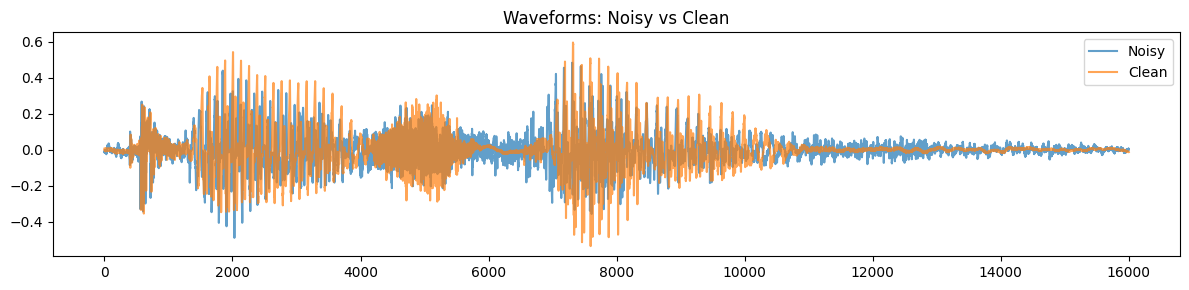

In [6]:
# Loading a sample from dataset
noisy, clean = dataset[1] #tensor
# Convert tensors to numpy arrays
noisy_np = noisy.squeeze().numpy()
clean_np = clean.squeeze().numpy()
sr = dataset.sr   # Sample rate: 16khz as defined in dataset preprocessing



# === 1. Waveform ===
plt.figure(figsize=(12, 3))
plt.plot(noisy_np, label="Noisy", alpha = 0.7)
plt.plot(clean_np, label="Clean", alpha=0.7)
plt.legend()
plt.title("Waveforms: Noisy vs Clean")
plt.tight_layout()
plt.show()


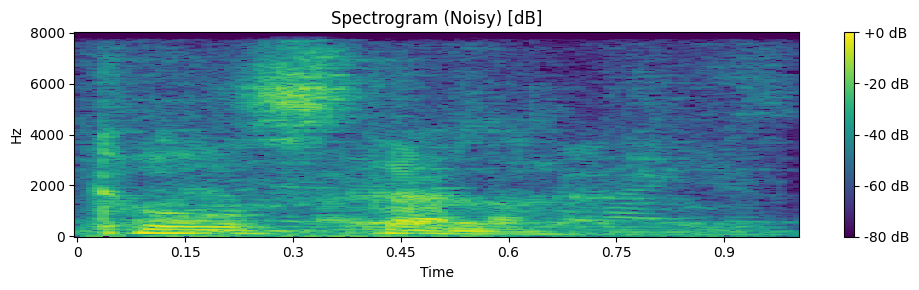

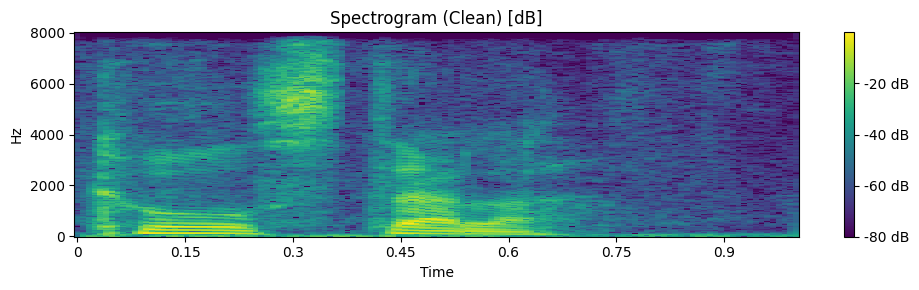

In [7]:
# === 2. Spectrogram (in dB) ===
def plot_spectrogram_db(signal, sr, title):
    S = librosa.stft(signal, n_fft=512, hop_length=128)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    plt.figure(figsize=(10, 3))
    librosa.display.specshow(S_db, sr=sr, hop_length=128, x_axis='time', y_axis='hz', cmap='viridis')
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_spectrogram_db(noisy_np, sr, "Spectrogram (Noisy) [dB]")
plot_spectrogram_db(clean_np, sr, "Spectrogram (Clean) [dB]")

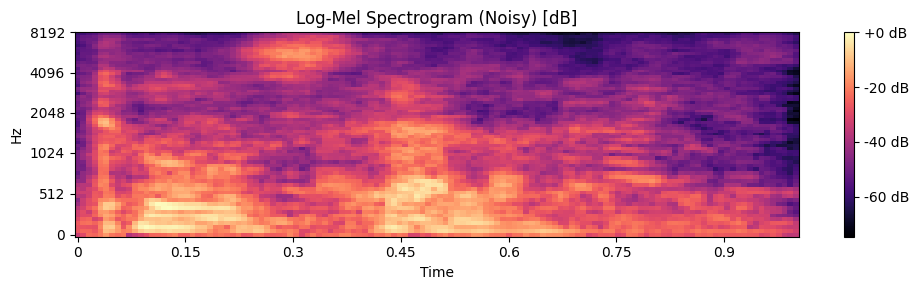

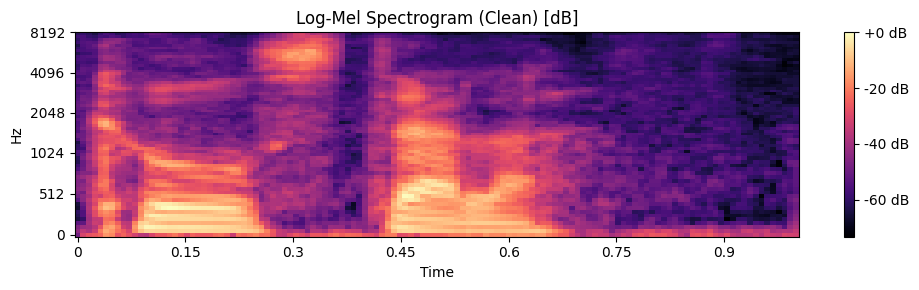

In [8]:
# === 3. Log-Mel Spectrogram (in dB) ===
def plot_logmel_db(signal, sr, title):
    mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=512, hop_length=128, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    plt.figure(figsize=(10, 3))
    librosa.display.specshow(mel_db, sr=sr, hop_length=128, x_axis='time', y_axis='mel', cmap='magma')
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_logmel_db(noisy_np, sr, "Log-Mel Spectrogram (Noisy) [dB]")
plot_logmel_db(clean_np, sr, "Log-Mel Spectrogram (Clean) [dB]")

In [9]:
from IPython.display import Audio
# play sample audio (1sec of entire file) from noisy and clean datasets
print("Noisy audio")
Audio(data=noisy, rate=dataset.sr)


Noisy audio


In [10]:
print("Clean audio")
Audio(data=clean, rate=dataset.sr)

Clean audio
